In [3]:
import pandas as pd

# Đọc file (đảm bảo đường dẫn đúng với thư mục bạn đang để file .csv)
df = pd.read_csv('../data/processed/processed_retail_data.csv', nrows=100)

# Tạo biến features
features = df.drop(columns=['Product_ID'])
print("Đã nạp dữ liệu xong! Bạn có", len(features), "dòng.")

Đã nạp dữ liệu xong! Bạn có 100 dòng.


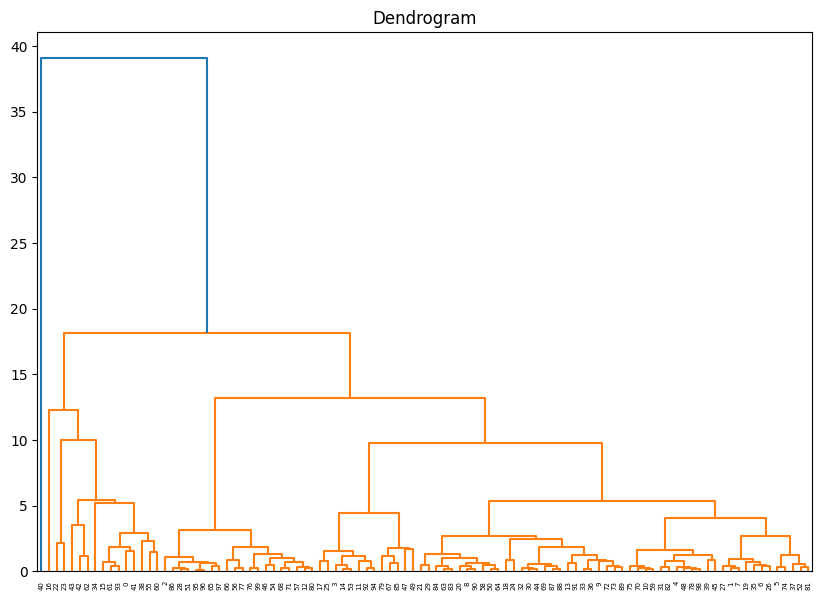

In [4]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
# Bây giờ biến 'features' đã có trong bộ nhớ, nó sẽ chạy được
dendrogram = sch.dendrogram(sch.linkage(features, method='ward')) 
plt.title('Dendrogram')
plt.show()

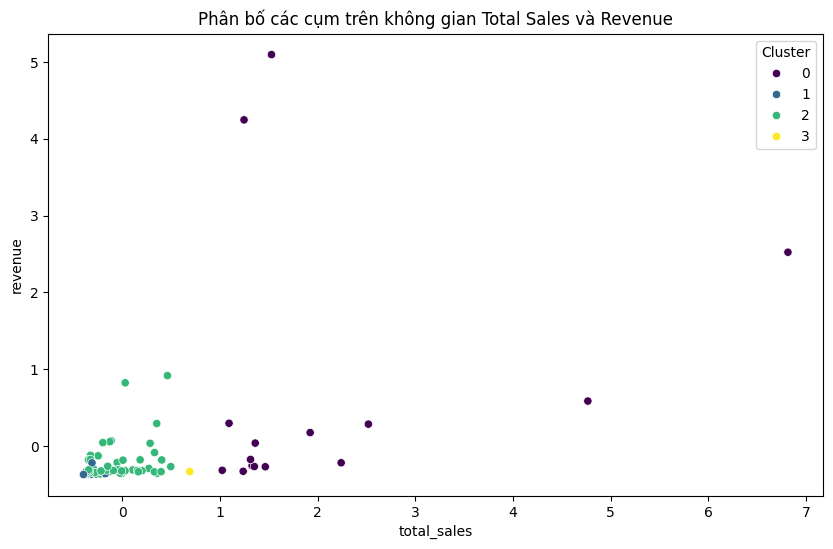

In [9]:
# 1. Nạp lại dữ liệu (chỉ cần nrows=100 như bạn đã làm)
df = pd.read_csv('../data/processed/processed_retail_data.csv', nrows=100)
features = df.drop(columns=['Product_ID'])

# 2. Chạy lại thuật toán để tạo cột 'Cluster' ngay trong tệp này
from sklearn.cluster import AgglomerativeClustering
model = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
df['Cluster'] = model.fit_predict(features)

# 3. Bây giờ mới vẽ biểu đồ (lúc này 'Cluster' đã tồn tại trong 'df')
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='total_sales', y='revenue', hue='Cluster', palette='viridis')
plt.title('Phân bố các cụm trên không gian Total Sales và Revenue')
plt.show()

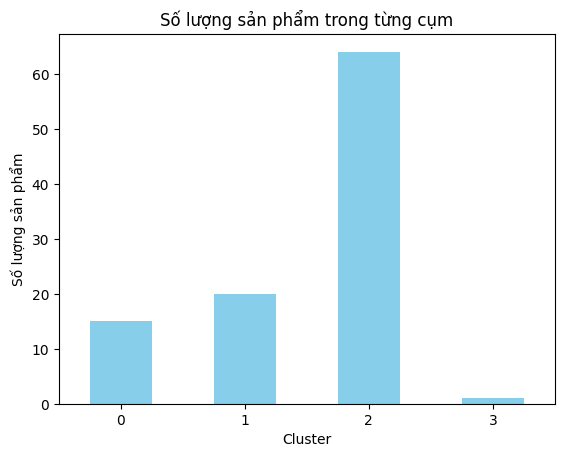

In [10]:
df['Cluster'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Số lượng sản phẩm trong từng cụm')
plt.xlabel('Cluster')
plt.ylabel('Số lượng sản phẩm')
plt.xticks(rotation=0)
plt.show()